## Non-Linear and Quadratic Methods

### Kernel PCA (KPCA)
Standard PCA is linear. If data is shaped like concentric circles, PCA fails to reduce dimensions effectively.
* **Concept:** Uses the **Kernel Trick** to project data into a higher-dimensional space (infinite dimensions) where it becomes linearly separable, then performs PCA in that space.
* **Kernels:** RBF (Radial Basis Function), Polynomial, Sigmoid.



### Quadratic Discriminant Analysis (QDA)
QDA is a classifier and dimensionality reduction technique similar to LDA, but with a twist.
* **LDA Assumption:** All classes share the same covariance matrix (same shape/spread).
* **QDA Assumption:** Each class has its own covariance matrix.
* **Result:** The decision boundary is **Quadratic** (curved) rather than Linear.

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles, make_moons
from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

#### 2) Making Data:

In [2]:
# Circle Data:
X_circle, y_circle = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=42)

# Moon Data:
X_moon, y_moon = make_moons(n_samples=500, noise=0.3, random_state=42)

In [4]:
print(X_circle.shape)
print(y_circle.shape)
print(X_moon.shape)
print(y_moon.shape)

(400, 2)
(400,)
(500, 2)
(500,)


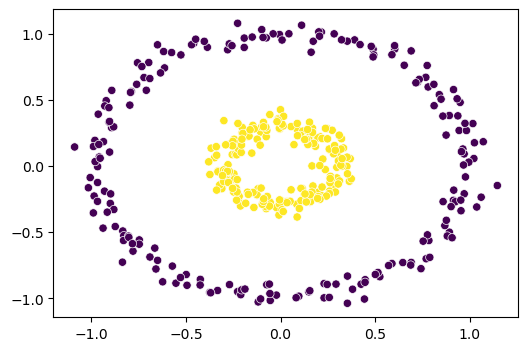

In [6]:
# Visualization of Circle Data:

plt.figure(figsize= (6,4))
sns.scatterplot(x= X_circle[:, 0], y= X_circle[:, 1], c= y_circle)
plt.show()

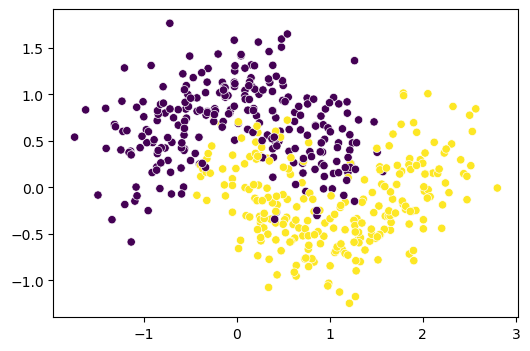

In [9]:
# Visualization of Moon Data:

plt.figure(figsize= (6,4))
sns.scatterplot(x= X_moon[:, 0], y= X_moon[:, 1], c= y_moon)
plt.show()

#### 3) PCA and KPCA on Circle Data:

In [14]:
kpca = KernelPCA(kernel= 'rbf', fit_inverse_transform= True, gamma= 10)
pca = PCA(n_components= 2)

In [15]:
# Fitting PCA and KPCA on Cirlce Data:

X_kpca = kpca.fit_transform(X_circle)
X_pca = pca.fit_transform(X_circle)

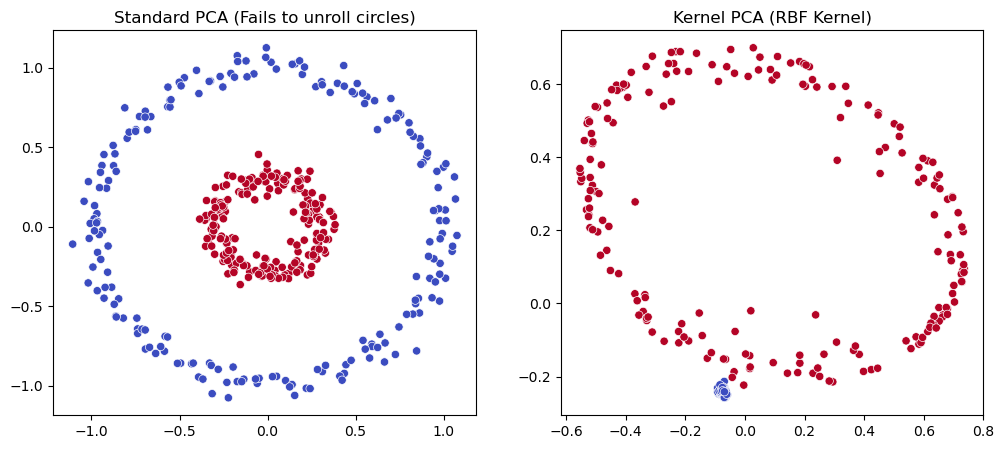

In [18]:
# Visualizing PCA and KPCA on Circle Data:

plt.figure(figsize=(12, 5))

# PCA:
plt.subplot(1, 2, 1)
sns.scatterplot(x= X_pca[:, 0], y= X_pca[:, 1], c=y_circle, cmap='coolwarm')
plt.title("Standard PCA (Fails to unroll circles)")

# KPCA:
plt.subplot(1, 2, 2)
sns.scatterplot(x= X_kpca[:, 0], y= X_kpca[:, 1], c=y_circle, cmap='coolwarm')
plt.title("Kernel PCA (RBF Kernel)")

plt.show()

The visualization above highlights the critical difference between **Linear** and **Non-Linear** dimensionality reduction.

#### 1. Standard PCA (Linear):
* **Observation:** The structure looks almost identical to the original dataset. The Red class is still surrounded by the Blue class (concentric circles).
* **The Reason:** PCA is a **Linear Transformation**. It can only rotate, flip, or scale the axes. It looks for lines of maximum variance.
* **The Limitation:** Imagine drawing a straight line on a piece of paper. You cannot separate the inner red circle from the outer blue circle with a single straight line. Since PCA preserves this linear structure, the data remains inseparable in the lower dimension.

#### 2. Kernel PCA (Non-Linear):
* **Observation:** The geometry of the data has fundamentally changed. The "concentric" (ring-inside-a-ring) structure is gone. The Blue points are now clustered in a tight blob, and the Red points are spread out in a distinct arc/loop separate from the blue.
* **The Reason:** KPCA uses the **Kernel Trick** (specifically the RBF kernel here). It implicitly projects the data into a higher-dimensional space (3D or more) where these circles might look like a "cone" or "mountain."
    * The inner circle (Red) maps to the peak of the mountain.
    * The outer circle (Blue) maps to the base of the mountain.
* **The Result:** When we project this high-dimensional shape back down to 2D (the plot you see), the classes have been "unrolled" or "warped" apart.
* **Significance:** Notice that now, you *could* almost draw a straight line (or a very simple curve) to slice the Blue cluster away from the Red arc. The data is now **linearly separable**, which makes it much easier for a classifier (like Logistic Regression) to handle.

#### 4) LDA and QDA on Moon Data:

In [19]:
print(X_moon.shape)
print(y_moon.shape)

(500, 2)
(500,)


In [20]:
X_train, X_test, y_train, y_test = train_test_split(X_moon, y_moon, test_size=0.2, random_state= 42)

In [21]:
# LDA:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
acc_lda = accuracy_score(y_test, lda.predict(X_test))

In [22]:
# QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
acc_qda = accuracy_score(y_test, qda.predict(X_test))

In [23]:
print(f"LDA Accuracy (Linear Boundary): {acc_lda:.4f}")
print(f"QDA Accuracy (Curved Boundary): {acc_qda:.4f}")

LDA Accuracy (Linear Boundary): 0.8500
QDA Accuracy (Curved Boundary): 0.8500


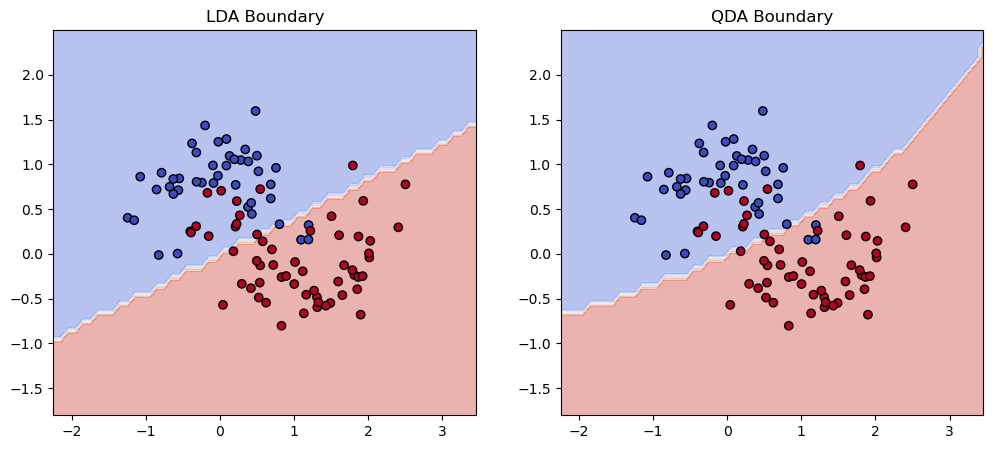

In [24]:
# Visualizing Decision Boundaries of LDA and QDA:

def plot_boundary(model, X, y, ax, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_boundary(lda, X_test, y_test, axes[0], "LDA Boundary")
plot_boundary(qda, X_test, y_test, axes[1], "QDA Boundary")
plt.show()

This visualization demonstrates why we sometimes need "Quadratic" methods over "Linear" ones, even for supervised classification.

#### 1. Linear Discriminant Analysis (LDA):
* **Observation:** The decision boundary (the line separating the blue area from the red area) is a perfect **straight line**.
* **The Reason:** LDA makes a strong assumption: **"Homoscedasticity."** In plain English, it assumes that the Red class and the Blue class have the exact same shape and spread (covariance), just shifted to different locations. Because of this, the math cancels out the "squared" terms, leaving only a linear equation ( $y = mx + c$ ).
* **The Limitation:** Look closely at the center. The data is shaped like two crescent moons curving into each other. A straight ruler cannot slide between two interlocking bananas without cutting through one of them. Consequently, LDA incorrectly classifies several Blue points in the middle as Red (and vice-versa). It is too rigid.

#### 2. Quadratic Discriminant Analysis (QDA):
* **Observation:** The decision boundary is **curved** (parabolic/hyperbolic). Notice how the red region "cups" the blue region, following the natural curve of the moon shape.
* **The Reason:** QDA relaxes the assumption. It says, "The Red class can have its own shape, and the Blue class can have a totally different shape." It calculates a separate covariance matrix for each class.
* **The Result:** Because it allows for different variances, the decision boundary becomes a quadratic equation ( $ax^2 + by^2 + ...$ ). This allows the model to draw a curve, significantly improving the separation in the middle where the two moons "hug" each other.
* **The Trade-off:** QDA is more flexible (lower bias), but because it has to estimate more parameters (separate covariance matrices for every class), it requires more data points to be reliable. If you have tiny data, QDA might overfit (hallucinate curves that aren't there).